Loading data...

[L1] 5-Fold Cross Validation...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

[L2] 5-Fold Cross Validation...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

── Cross Validation Results ──
  K=1  L1: 0.2922  |  L2: 0.2714
  K=3  L1: 0.2944  |  L2: 0.2764
  K=5  L1: 0.3014  |  L2: 0.2812
  K=7  L1: 0.3030  |  L2: 0.2772
  K=9  L1: 0.3056  |  L2: 0.2768

Best: K=9, Metric=L1

Final test evaluation...
Test Accuracy: 0.3010


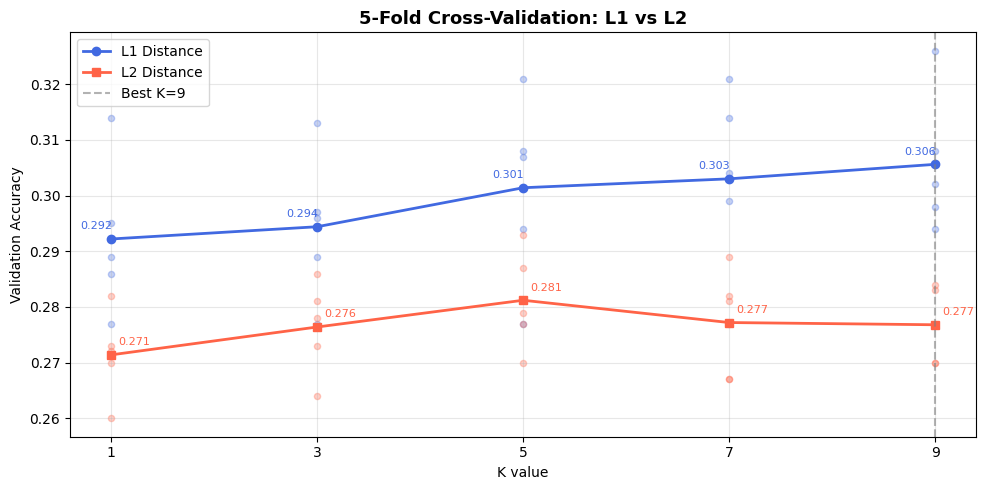

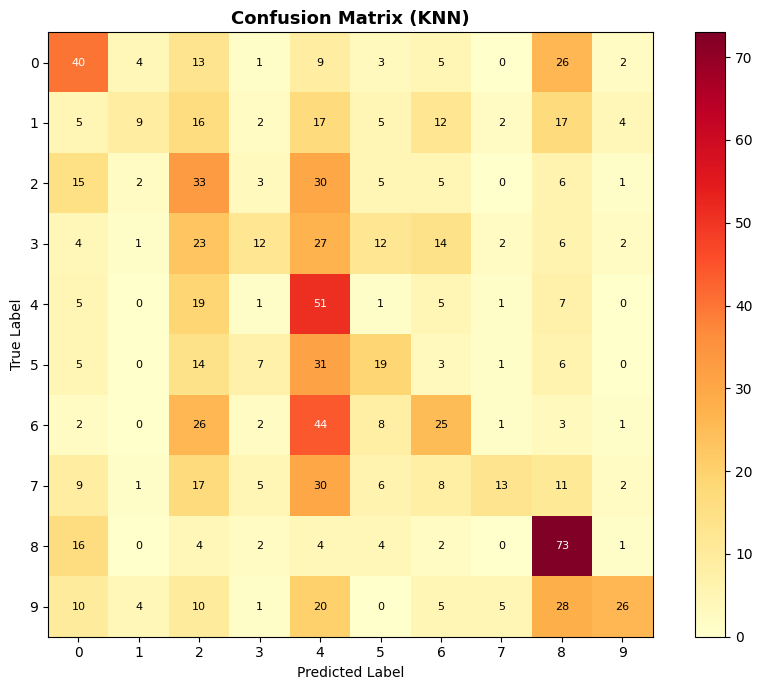

In [4]:
import tarfile
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from urllib.request import urlretrieve
import os

# ── CIFAR-10 자동 다운로드 ────────────────────
def download_cifar10():
    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    filename = "cifar-10-python.tar.gz"
    if not os.path.exists(filename):
        print("Downloading CIFAR-10 dataset...")
        urlretrieve(url, filename)
        print("Download complete.")
    return filename

# ── 데이터 로드 ───────────────────────────────
def load_data(tar_path, n_train=5000, n_test=1000):
    train_data, train_labels = [], []
    test_data, test_labels = None, None

    with tarfile.open(tar_path, 'r:gz') as tar:
        for member in tar.getmembers():
            name = member.name

            # data_batch 또는 test_batch 파일만 처리
            if 'data_batch' not in name and 'test_batch' not in name:
                continue

            f = tar.extractfile(member)
            if f is None:
                continue

            batch = pickle.load(f, encoding='bytes')

            if 'data_batch' in name:
                train_data.append(batch[b'data'])
                train_labels.extend(batch[b'labels'])
            elif 'test_batch' in name:
                test_data = batch[b'data']
                test_labels = np.array(batch[b'labels'])

    X_train = np.concatenate(train_data)[:n_train].astype(np.float32)
    y_train = np.array(train_labels)[:n_train]
    X_test  = test_data[:n_test].astype(np.float32)
    y_test  = test_labels[:n_test]

    return X_train, y_train, X_test, y_test

# ── KNN 클래스 ────────────────────────────────
class KNNClassifier:
    def __init__(self, k=1, metric='l2'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _compute_distances(self, X):
        if self.metric == 'l1':
            return np.array([
                np.sum(np.abs(self.X_train - x), axis=1) for x in X
            ])
        else:  # l2
            return np.array([
                np.sqrt(np.sum((self.X_train - x) ** 2, axis=1)) for x in X
            ])

    def predict(self, X):
        dists = self._compute_distances(X)
        predictions = []
        for row in dists:
            neighbor_labels = self.y_train[np.argsort(row)[:self.k]]
            predictions.append(Counter(neighbor_labels).most_common(1)[0][0])
        return np.array(predictions)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# ── K-Fold 교차 검증 ──────────────────────────
def cross_validate(X, y, k_list, n_folds=5, metric='l1'):
    fold_X = np.array_split(X, n_folds)
    fold_y = np.array_split(y, n_folds)
    results = {k: [] for k in k_list}

    for fold in range(n_folds):
        X_val = fold_X[fold]
        y_val = fold_y[fold]
        X_tr  = np.concatenate(fold_X[:fold] + fold_X[fold+1:])
        y_tr  = np.concatenate(fold_y[:fold] + fold_y[fold+1:])

        for k in k_list:
            clf = KNNClassifier(k=k, metric=metric)
            clf.fit(X_tr, y_tr)
            acc = clf.score(X_val, y_val)
            results[k].append(acc)
        print(f"  Fold {fold+1}/{n_folds} done")

    return results

# ── 혼동 행렬 시각화 ──────────────────────────
def show_confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    fig, ax = plt.subplots(figsize=(9, 7))
    img = ax.imshow(cm, cmap='YlOrRd')
    fig.colorbar(img, ax=ax)

    ax.set_title('Confusion Matrix (KNN)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))

    threshold = cm.max() / 2
    for i in range(n_classes):
        for j in range(n_classes):
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=8, color=color)
    plt.tight_layout()
    plt.show()

# ── 교차 검증 결과 시각화 ─────────────────────
def plot_cv_results(k_list, acc_l1, acc_l2, best_k):
    mean_l1 = [np.mean(acc_l1[k]) for k in k_list]
    mean_l2 = [np.mean(acc_l2[k]) for k in k_list]

    fig, ax = plt.subplots(figsize=(10, 5))

    for k in k_list:
        ax.scatter([k]*len(acc_l1[k]), acc_l1[k], color='royalblue', alpha=0.3, s=20)
        ax.scatter([k]*len(acc_l2[k]), acc_l2[k], color='tomato',    alpha=0.3, s=20)

    ax.plot(k_list, mean_l1, 'o-', color='royalblue', linewidth=2, label='L1 Distance')
    ax.plot(k_list, mean_l2, 's-', color='tomato',    linewidth=2, label='L2 Distance')

    for k, a1, a2 in zip(k_list, mean_l1, mean_l2):
        ax.annotate(f'{a1:.3f}', (k, a1), textcoords='offset points',
                    xytext=(-22, 7), fontsize=8, color='royalblue')
        ax.annotate(f'{a2:.3f}', (k, a2), textcoords='offset points',
                    xytext=(5, 7),  fontsize=8, color='tomato')

    ax.axvline(x=best_k, color='gray', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
    ax.set_title('5-Fold Cross-Validation: L1 vs L2', fontsize=13, fontweight='bold')
    ax.set_xlabel('K value')
    ax.set_ylabel('Validation Accuracy')
    ax.set_xticks(k_list)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── 메인 실행 ─────────────────────────────────
if __name__ == "__main__":
    tar_path = download_cifar10()

    print("Loading data...")
    X_train, y_train, X_test, y_test = load_data(tar_path, n_train=5000, n_test=1000)

    # flatten: (N, 3072)
    X_train = X_train.reshape(len(X_train), -1)
    X_test  = X_test.reshape(len(X_test), -1)

    k_list = [1, 3, 5, 7, 9]

    print("\n[L1] 5-Fold Cross Validation...")
    cv_l1 = cross_validate(X_train, y_train, k_list, metric='l1')

    print("\n[L2] 5-Fold Cross Validation...")
    cv_l2 = cross_validate(X_train, y_train, k_list, metric='l2')

    mean_l1 = {k: np.mean(cv_l1[k]) for k in k_list}
    mean_l2 = {k: np.mean(cv_l2[k]) for k in k_list}

    print("\n── Cross Validation Results ──")
    for k in k_list:
        print(f"  K={k}  L1: {mean_l1[k]:.4f}  |  L2: {mean_l2[k]:.4f}")

    best_k = max(mean_l1, key=mean_l1.get)
    print(f"\nBest: K={best_k}, Metric=L1")

    print("\nFinal test evaluation...")
    final_clf = KNNClassifier(k=best_k, metric='l1')
    final_clf.fit(X_train, y_train)
    y_pred = final_clf.predict(X_test)
    print(f"Test Accuracy: {np.mean(y_pred == y_test):.4f}")

    plot_cv_results(k_list, cv_l1, cv_l2, best_k)
    show_confusion_matrix(y_test, y_pred)